# Scoring

The distribution of each attribute and of the score, how much road passes when one threshold moves, and which roads near a station have the most passing length.

Run `uv run roadcycling fetch` and `uv run roadcycling build` first.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

from roadcycling import config, score

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
cfg = config.load(ROOT / "config.toml")
segs = gpd.read_file(ROOT / "data/processed/segments.gpkg", layer="segments")
BLUE = "#2a78d6"
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#52514e",
        "axes.labelcolor": "#0b0b0b",
        "xtick.color": "#52514e",
        "ytick.color": "#52514e",
    }
)

## Distributions

Each histogram counts kilometres of carriageway, not segments.

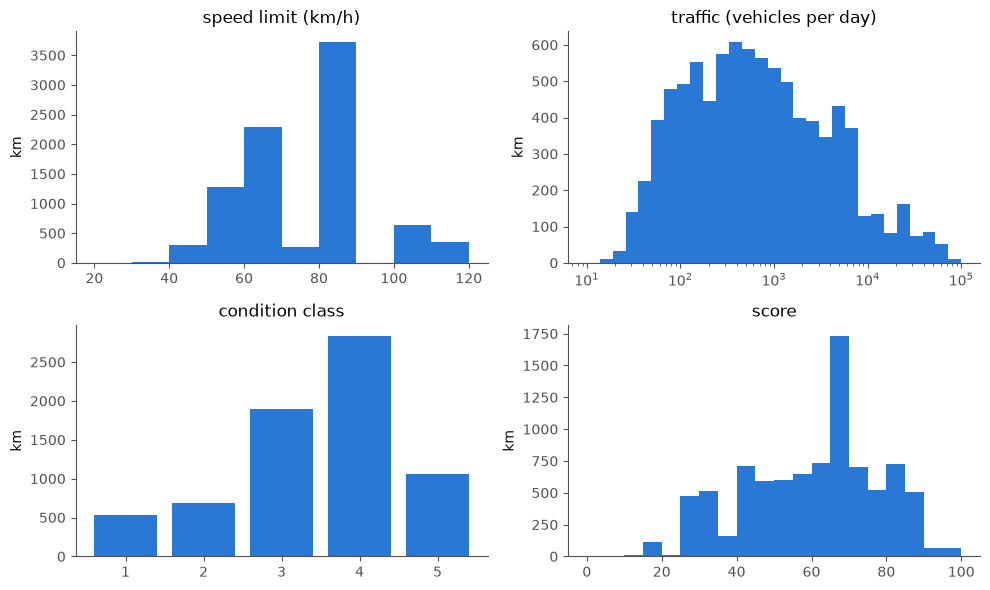

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
w = segs["length_m"] / 1000
axes[0, 0].hist(
    segs.speed_limit.dropna(),
    bins=range(20, 130, 10),
    weights=w[segs.speed_limit.notna()],
    color=BLUE,
)
axes[0, 0].set(title="speed limit (km/h)", ylabel="km")
kvl = segs.kvl.dropna()
axes[0, 1].hist(kvl.clip(lower=10), bins=np.logspace(1, 5, 30), weights=w[kvl.index], color=BLUE)
axes[0, 1].set(xscale="log", title="traffic (vehicles per day)", ylabel="km")
axes[1, 0].hist(
    segs.condition.dropna(),
    bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
    weights=w[segs.condition.notna()],
    color=BLUE,
    rwidth=0.8,
)
axes[1, 0].set(title="condition class", ylabel="km")
axes[1, 1].hist(
    segs.score.dropna(), bins=range(0, 105, 5), weights=w[segs.score.notna()], color=BLUE
)
axes[1, 1].set(title="score", ylabel="km")
fig.tight_layout()

## Moving one threshold

Each panel moves one threshold and keeps the others at their `config.toml` values. The dotted line marks the current value.

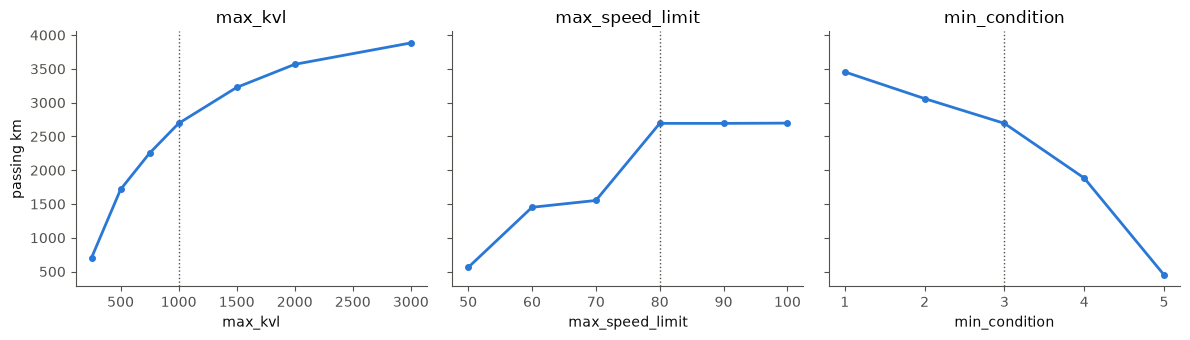

In [3]:
from dataclasses import replace


def passing_km(**change):
    c = replace(cfg, **change)
    return segs.loc[score.passes(segs, c), "length_m"].sum() / 1000


sweeps = {
    "max_kvl": [250, 500, 750, 1000, 1500, 2000, 3000],
    "max_speed_limit": [50, 60, 70, 80, 90, 100],
    "min_condition": [1, 2, 3, 4, 5],
}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, (name, values) in zip(axes, sweeps.items(), strict=True):
    ax.plot(
        values,
        [passing_km(**{name: v}) for v in values],
        color=BLUE,
        marker="o",
        markersize=4,
        linewidth=2,
    )
    ax.axvline(getattr(cfg, name), color="#52514e", linewidth=1, linestyle=":")
    ax.set(xlabel=name, title=name)
axes[0].set_ylabel("passing km")
fig.tight_layout()

## Roads with the most passing length near a station

Passing segments within `NEAR_KM` of a rail or metro station, summed per road. The score is the length-weighted mean over those segments.

In [4]:
NEAR_KM = 15


def top_roads(c, n=15):
    ok = score.passes(segs, c) & (segs.station_km <= NEAR_KM)
    near = segs[ok].assign(weighted=lambda d: d.score * d.length_m)
    g = near.groupby(["tie", "name"], dropna=False).agg(
        m=("length_m", "sum"),
        weighted=("weighted", "sum"),
        station=("station_name", "first"),
        station_km=("station_km", "min"),
    )
    g["km"] = g.m / 1000
    g["score"] = g.weighted / g.m
    return (
        g.sort_values("km", ascending=False)
        .head(n)[["km", "score", "station", "station_km"]]
        .round(1)
    )


top_roads(cfg)

,,km,score,station,station_km
tie,name,,,,
1050,Raasepori-Inkoo,26.0,76.7,Dragsvik,2.3
11007,Lappohja-Täktom,18.4,80.9,Lappohja,0.1
2951,Kivelä-Lammi,17.7,72.8,Mommila,0.4
1081,Tenhola-Bromarv,16.6,61.8,Tammisaari,12.6
1471,Mäntsälä-Oitti,16.3,65.6,Mäntsälä,0.7
1635,Monninkylä-Tönnö,16.0,64.5,Henna,10.1
13857,Saloinen-Löyttymäki-Puujaa,16.0,81.7,Turenki,7.3
2954,Marttila-Hälvälä,15.9,77.1,Herrala,0.3
1731,Kansanmäki-Artjärvi,15.7,64.0,Kausala,0.7
